# 🏎️ F1 2024 — Lap Time Prediction

**Goal:** Predict an F1 lap time (in seconds) given tyre compound, tyre age, lap number, driver, constructor, circuit, and weather conditions.

**Data source:** [FastF1](https://docs.fastf1.dev/) — real 2024 season telemetry & timing data  
**Models:** Linear Regression (baseline) → Random Forest → XGBoost  
**Metrics:** MAE, RMSE, R²

---

## 0. Install Dependencies

In [1]:
# Run this once if you haven't installed the packages yet
!pip install fastf1 xgboost scikit-learn matplotlib pandas numpy joblib

Defaulting to user installation because normal site-packages is not writeable


## 1. Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

# Enable FastF1 cache (avoids re-downloading data)
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE_DIR))

# ── Config ────────────────────────────────────────────────
YEAR       = 2024
ROUNDS     = list(range(1, 11))   # Rounds 1–10; increase for more data
MIN_LAPS   = 3                    # Skip out-laps
MIN_LAP_SEC = 60                  # Remove unrealistically fast laps
MAX_LAP_SEC = 130                 # Remove safety car / anomaly laps

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Data Collection

We load race sessions using `fastf1` and extract per-lap features.  
**This will take 5–10 minutes** the first time (downloads data). Subsequent runs use the local cache and are fast.

In [3]:
def collect_data(year, rounds):
    records = []
    for rnd in rounds:
        try:
            session = fastf1.get_session(year, rnd, "R")
            session.load(laps=True, telemetry=False, weather=True, messages=False)
            laps = session.laps.copy()

            # Keep clean flying laps with a known tyre compound
            laps = laps[laps["Compound"].notna()]
            laps = laps[laps["LapNumber"] >= MIN_LAPS]
            laps = laps[laps["IsPersonalBest"].notna()]

            weather = session.weather_data
            avg_track_temp = weather["TrackTemp"].mean() if weather is not None and not weather.empty else np.nan
            avg_air_temp   = weather["AirTemp"].mean()   if weather is not None and not weather.empty else np.nan

            for _, lap in laps.iterrows():
                lt = lap["LapTime"]
                if pd.isna(lt):
                    continue
                lt_sec = lt.total_seconds()
                if not (MIN_LAP_SEC <= lt_sec <= MAX_LAP_SEC):
                    continue

                records.append({
                    "LapTimeSec" : lt_sec,
                    "LapNumber"  : lap["LapNumber"],
                    "Compound"   : lap["Compound"],
                    "TyreLife"   : lap["TyreLife"] if not pd.isna(lap["TyreLife"]) else 0,
                    "Driver"     : lap["Driver"],
                    "Team"       : lap["Team"],
                    "EventName"  : session.event["EventName"],
                    "Round"      : rnd,
                    "TrackTemp"  : avg_track_temp,
                    "AirTemp"    : avg_air_temp,
                })

            print(f"  Round {rnd:>2} ✓ {session.event['EventName']} — cumulative laps: {len(records)}")

        except Exception as e:
            print(f"  Round {rnd:>2} ✗ skipped ({e})")

    return pd.DataFrame(records)


df = collect_data(YEAR, ROUNDS)
df.to_csv("laps_raw.csv", index=False)
print(f"\n📦 Total laps collected: {len(df):,}")
df.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

core        WARNING 	Driver 1 completed the race distance 00:00.015000 before the recorded end of the session.


req            INFO 	Using cached data for weather_data


core           INFO 	Finished loading data for 20 drivers: ['1', '4', '44', '63', '16', '55', '81', '11', '10', '31', '27', '14', '24', '18', '3', '77', '20', '23', '22', '2']


  Round 10 ✓ Spanish Grand Prix — cumulative laps: 10457

📦 Total laps collected: 10,457


,LapTimeSec,LapNumber,Compound,TyreLife,Driver,Team,EventName,Round,TrackTemp,AirTemp
0,96.753,3.0,SOFT,6.0,VER,Red Bull Racing,Bahrain Grand Prix,1,23.652866,18.227389
1,96.647,4.0,SOFT,7.0,VER,Red Bull Racing,Bahrain Grand Prix,1,23.652866,18.227389
2,97.173,5.0,SOFT,8.0,VER,Red Bull Racing,Bahrain Grand Prix,1,23.652866,18.227389
3,97.092,6.0,SOFT,9.0,VER,Red Bull Racing,Bahrain Grand Prix,1,23.652866,18.227389
4,97.038,7.0,SOFT,10.0,VER,Red Bull Racing,Bahrain Grand Prix,1,23.652866,18.227389


## 3. Exploratory Data Analysis

In [4]:
print("Dataset shape:", df.shape)
print("\nCompound distribution:")
print(df["Compound"].value_counts())
print("\nLap time stats (seconds):")
print(df["LapTimeSec"].describe().round(3))

Dataset shape: (10457, 10)

Compound distribution:
Compound
HARD            5576
MEDIUM          3043
SOFT            1049
INTERMEDIATE     774
WET               15
Name: count, dtype: int64

Lap time stats (seconds):
count    10457.000
mean        89.804
std          9.596
min         74.165
25%         81.387
50%         90.060
75%         96.646
max        129.998
Name: LapTimeSec, dtype: float64


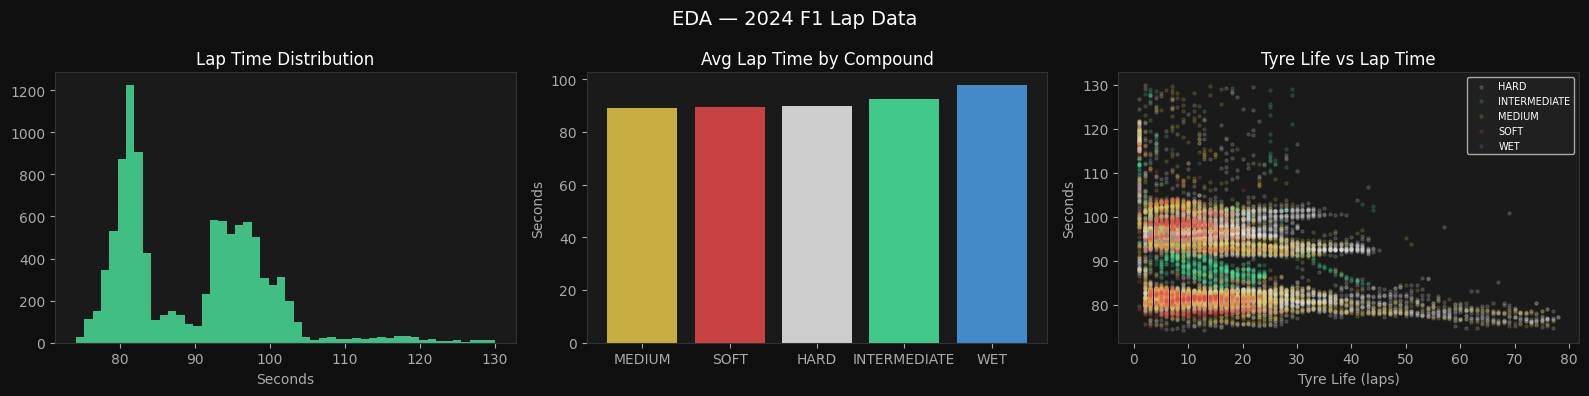

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor="#0f0f0f")
fig.suptitle("EDA — 2024 F1 Lap Data", color="white", fontsize=14)

compound_colors = {"SOFT": "#e84a4a", "MEDIUM": "#e8c84a", "HARD": "#eeeeee",
                   "INTERMEDIATE": "#4ae8a0", "WET": "#4a9fe8"}

# Plot 1: Lap time distribution
ax = axes[0]
ax.hist(df["LapTimeSec"], bins=50, color="#4ae8a0", edgecolor="none", alpha=0.8)
ax.set_title("Lap Time Distribution", color="white")
ax.set_xlabel("Seconds", color="#aaa")
ax.set_facecolor("#1a1a1a")
ax.tick_params(colors="#aaa")
for s in ax.spines.values(): s.set_edgecolor("#333")

# Plot 2: Average lap time by compound
ax = axes[1]
comp_means = df.groupby("Compound")["LapTimeSec"].mean().sort_values()
bars = ax.bar(comp_means.index, comp_means.values,
              color=[compound_colors.get(c, "#888") for c in comp_means.index], alpha=0.85)
ax.set_title("Avg Lap Time by Compound", color="white")
ax.set_ylabel("Seconds", color="#aaa")
ax.set_facecolor("#1a1a1a")
ax.tick_params(colors="#aaa")
for s in ax.spines.values(): s.set_edgecolor("#333")

# Plot 3: Tyre life vs lap time scatter
ax = axes[2]
for compound, grp in df.groupby("Compound"):
    ax.scatter(grp["TyreLife"], grp["LapTimeSec"],
               alpha=0.15, s=5,
               color=compound_colors.get(compound, "#888"),
               label=compound)
ax.set_title("Tyre Life vs Lap Time", color="white")
ax.set_xlabel("Tyre Life (laps)", color="#aaa")
ax.set_ylabel("Seconds", color="#aaa")
ax.set_facecolor("#1a1a1a")
ax.tick_params(colors="#aaa")
for s in ax.spines.values(): s.set_edgecolor("#333")
ax.legend(fontsize=7, facecolor="#222", labelcolor="white")

plt.tight_layout()
plt.show()

## 4. Feature Engineering

| Feature | Rationale |
|---|---|
| `LapNumber` | Fuel burn-off effect — lighter car = faster laps |
| `LapFrac` | Normalised lap position across different race lengths |
| `TyreLife` | Core degradation driver |
| `TyreLife²` | Non-linear degradation curve |
| `Compound` | SOFT/MEDIUM/HARD have different grip & deg profiles |
| `Driver` | Driver pace delta |
| `Team` | Car performance baseline |
| `EventName` | Circuit-specific lap time baseline |
| `TrackTemp` | Higher temp = more grip but also higher deg |
| `AirTemp` | Affects engine & aero performance |

In [6]:
def build_features(df):
    df = df.copy()
    encoders = {}

    # Label-encode categoricals
    for col in ["Compound", "Driver", "Team", "EventName"]:
        enc = LabelEncoder()
        df[col + "_enc"] = enc.fit_transform(df[col].astype(str))
        encoders[col] = enc

    # Non-linear tyre degradation
    df["TyreLife2"] = df["TyreLife"] ** 2

    # Normalised lap position (fuel load proxy)
    df["LapFrac"] = df["LapNumber"] / df.groupby("Round")["LapNumber"].transform("max")

    feature_cols = [
        "LapNumber", "LapFrac",
        "TyreLife", "TyreLife2",
        "Compound_enc",
        "Driver_enc",
        "Team_enc",
        "EventName_enc",
        "TrackTemp", "AirTemp",
    ]

    X = df[feature_cols].fillna(df[feature_cols].median())
    y = df["LapTimeSec"]
    return X, y, encoders, feature_cols


X, y, encoders, feature_cols = build_features(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features : {feature_cols}")
print(f"Train set: {len(X_train):,} laps")
print(f"Test set : {len(X_test):,} laps")

Features : ['LapNumber', 'LapFrac', 'TyreLife', 'TyreLife2', 'Compound_enc', 'Driver_enc', 'Team_enc', 'EventName_enc', 'TrackTemp', 'AirTemp']
Train set: 8,365 laps
Test set : 2,092 laps


## 5. Model Training

### 5.1 Baseline — Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_mae   = mean_absolute_error(y_test, lr_preds)
lr_rmse  = mean_squared_error(y_test, lr_preds) ** 0.5
lr_r2    = r2_score(y_test, lr_preds)

print(f"Linear Regression — MAE: {lr_mae:.3f}s | RMSE: {lr_rmse:.3f}s | R²: {lr_r2:.4f}")

Linear Regression — MAE: 5.337s | RMSE: 7.433s | R²: 0.4286


### 5.2 Random Forest

In [8]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_mae   = mean_absolute_error(y_test, rf_preds)
rf_rmse  = mean_squared_error(y_test, rf_preds) ** 0.5
rf_r2    = r2_score(y_test, rf_preds)

print(f"Random Forest      — MAE: {rf_mae:.3f}s | RMSE: {rf_rmse:.3f}s | R²: {rf_r2:.4f}")

Random Forest      — MAE: 1.238s | RMSE: 3.070s | R²: 0.9026


### 5.3 XGBoost

In [9]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test)
xgb_mae   = mean_absolute_error(y_test, xgb_preds)
xgb_rmse  = mean_squared_error(y_test, xgb_preds) ** 0.5
xgb_r2    = r2_score(y_test, xgb_preds)

print(f"XGBoost            — MAE: {xgb_mae:.3f}s | RMSE: {xgb_rmse:.3f}s | R²: {xgb_r2:.4f}")

XGBoost            — MAE: 1.134s | RMSE: 2.859s | R²: 0.9155


## 6. Results Summary

In [ ]:
results_df = pd.DataFrame([
    {"Model": "Linear Regression", "MAE (s)": lr_mae,  "RMSE (s)": lr_rmse,  "R²": lr_r2},
    {"Model": "Random Forest",     "MAE (s)": rf_mae,  "RMSE (s)": rf_rmse,  "R²": rf_r2},
    {"Model": "XGBoost",           "MAE (s)": xgb_mae, "RMSE (s)": xgb_rmse, "R²": xgb_r2},
]).set_index("Model").round(4)

print(results_df.to_string())
results_df


## 7. Visualisations

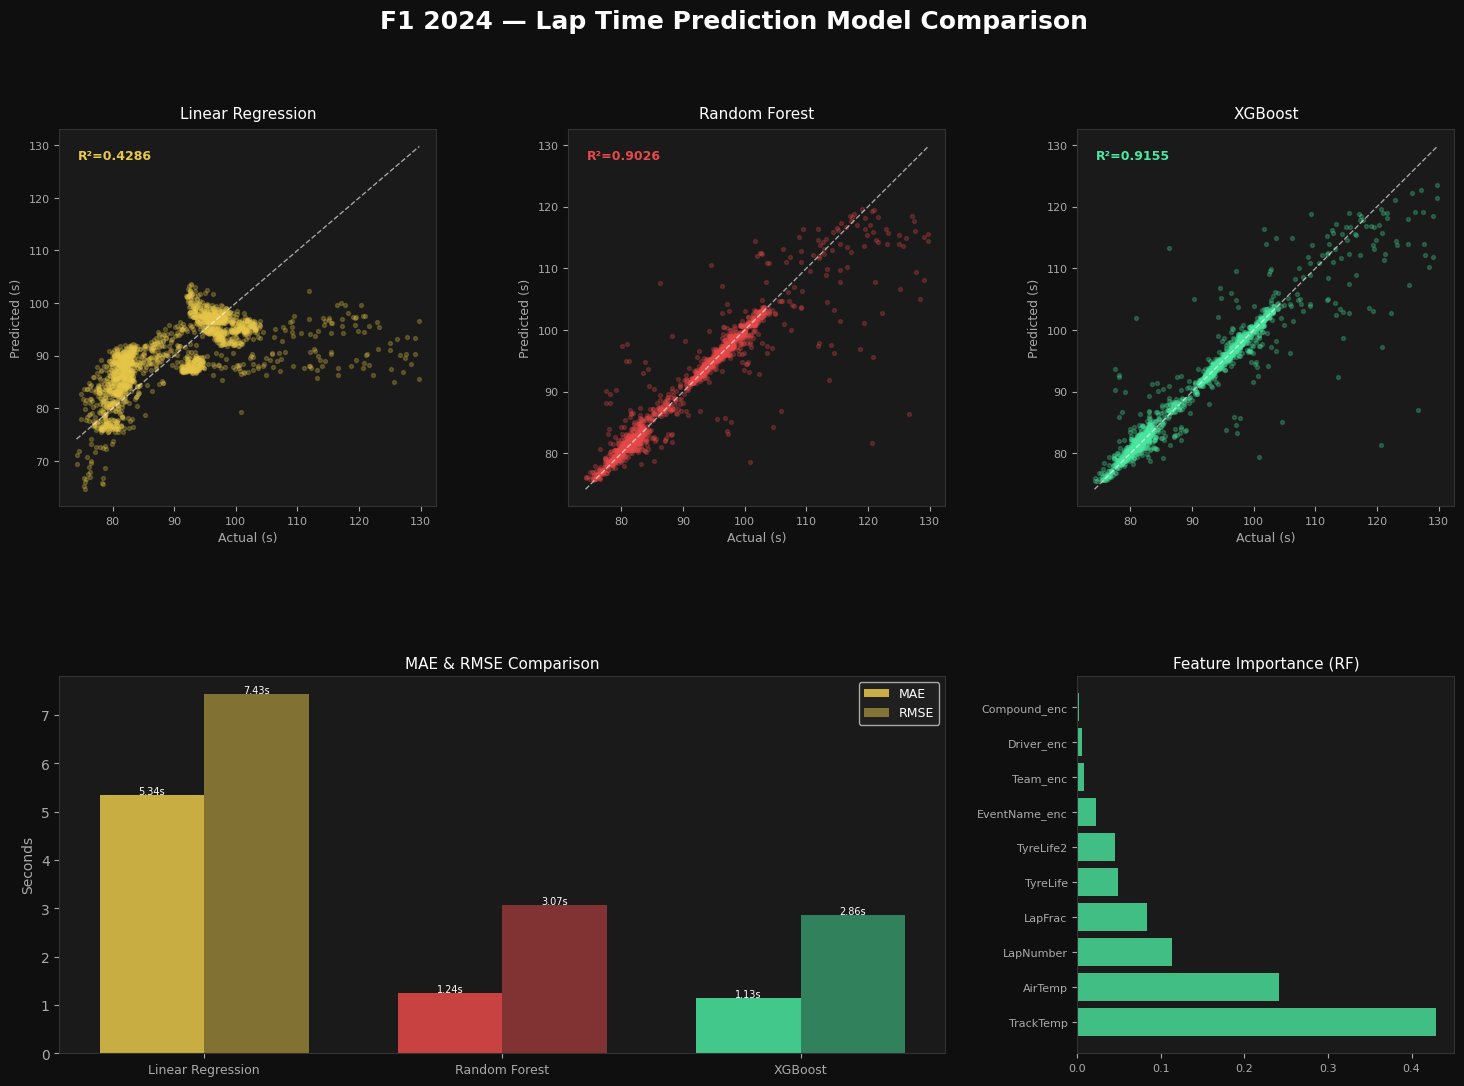

✅ Saved → results.png


In [11]:
results = [
    {"name": "Linear Regression", "preds": lr_preds,  "mae": lr_mae,  "rmse": lr_rmse,  "r2": lr_r2},
    {"name": "Random Forest",     "preds": rf_preds,  "mae": rf_mae,  "rmse": rf_rmse,  "r2": rf_r2},
    {"name": "XGBoost",           "preds": xgb_preds, "mae": xgb_mae, "rmse": xgb_rmse, "r2": xgb_r2},
]

colors = {"Linear Regression": "#e8c84a",
          "Random Forest":     "#e84a4a",
          "XGBoost":           "#4ae8a0"}

fig = plt.figure(figsize=(18, 12), facecolor="#0f0f0f")
fig.suptitle("F1 2024 — Lap Time Prediction Model Comparison",
             color="white", fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Row 1: Predicted vs Actual scatter
for i, res in enumerate(results):
    ax = fig.add_subplot(gs[0, i])
    c  = colors[res["name"]]
    ax.scatter(y_test, res["preds"], alpha=0.25, s=8, color=c)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], "w--", linewidth=1, alpha=0.6, label="Perfect")
    ax.set_title(res["name"], color="white", fontsize=11, pad=8)
    ax.set_xlabel("Actual (s)", color="#aaa", fontsize=9)
    ax.set_ylabel("Predicted (s)", color="#aaa", fontsize=9)
    ax.tick_params(colors="#aaa", labelsize=8)
    ax.set_facecolor("#1a1a1a")
    for s in ax.spines.values(): s.set_edgecolor("#333")
    ax.text(0.05, 0.92, f"R²={res['r2']:.4f}", transform=ax.transAxes,
            color=c, fontsize=9, fontweight="bold")

# Row 2 left: MAE & RMSE bar chart
ax2 = fig.add_subplot(gs[1, 0:2])
names = [r["name"] for r in results]
maes  = [r["mae"]  for r in results]
rmses = [r["rmse"] for r in results]
x, w = np.arange(len(names)), 0.35
b1 = ax2.bar(x - w/2, maes,  w, label="MAE",  color=[colors[n] for n in names], alpha=0.85)
b2 = ax2.bar(x + w/2, rmses, w, label="RMSE", color=[colors[n] for n in names], alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(names, color="white", fontsize=9)
ax2.set_ylabel("Seconds", color="#aaa")
ax2.set_title("MAE & RMSE Comparison", color="white", fontsize=11)
ax2.legend(facecolor="#222", labelcolor="white", fontsize=9)
ax2.set_facecolor("#1a1a1a")
ax2.tick_params(colors="#aaa")
for s in ax2.spines.values(): s.set_edgecolor("#333")
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}s", ha="center", color="white", fontsize=7)

# Row 2 right: RF Feature importance
ax3 = fig.add_subplot(gs[1, 2])
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
ax3.barh(range(len(feature_cols)), importances[indices], color="#4ae8a0", alpha=0.8)
ax3.set_yticks(range(len(feature_cols)))
ax3.set_yticklabels([feature_cols[i] for i in indices], color="white", fontsize=8)
ax3.set_title("Feature Importance (RF)", color="white", fontsize=11)
ax3.set_facecolor("#1a1a1a")
ax3.tick_params(colors="#aaa", labelsize=8)
for s in ax3.spines.values(): s.set_edgecolor("#333")

plt.savefig("results.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("✅ Saved → results.png")

## 8. Save Models

In [12]:
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(encoders,  "encoders.pkl")
print("✅ Models saved — xgb_model.pkl, encoders.pkl")

✅ Models saved — xgb_model.pkl, encoders.pkl


## 9. Inference — Predict a Custom Lap

Change the values below to predict any scenario.

In [13]:
def predict_lap_time(
    driver, team, event, compound,
    lap_number, tyre_life,
    total_laps=57, track_temp=40.0, air_temp=28.0
):
    def safe_encode(col, val):
        enc = encoders[col]
        return enc.transform([val])[0] if val in enc.classes_ else len(enc.classes_) // 2

    X_pred = pd.DataFrame([{
        "LapNumber"    : lap_number,
        "LapFrac"      : lap_number / total_laps,
        "TyreLife"     : tyre_life,
        "TyreLife2"    : tyre_life ** 2,
        "Compound_enc" : safe_encode("Compound", compound),
        "Driver_enc"   : safe_encode("Driver", driver),
        "Team_enc"     : safe_encode("Team", team),
        "EventName_enc": safe_encode("EventName", event),
        "TrackTemp"    : track_temp,
        "AirTemp"      : air_temp,
    }])

    return float(xgb_model.predict(X_pred)[0])


# ── Try it out ────────────────────────────────────────────
lap_time = predict_lap_time(
    driver     = "HAM",
    team       = "Mercedes",
    event      = "Bahrain Grand Prix",
    compound   = "SOFT",
    lap_number = 15,
    tyre_life  = 12,
    track_temp = 42.0,
    air_temp   = 29.0,
)

m, s = divmod(lap_time, 60)
print(f"🏎️  Predicted lap time: {int(m)}:{s:06.3f}  ({lap_time:.3f}s)")

🏎️  Predicted lap time: 1:31.992  (91.992s)
